# BANKING77 Deep Learning Baseline

This notebook implements a PyTorch-based deep learning baseline
for the 77-class customer ticket classification task.

Pipeline:

Text
→ Tokenization
→ Vocabulary
→ Integer Encoding
→ Padding
→ Embedding
→ TextCNN
→ 77-class Classification

In [1]:
# Cell 1：基础环境

from pathlib import Path
import random
import numpy as np
import pandas as pd

import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch version: 2.8.0+cu128
CUDA available: True


In [2]:
# Cell 2：固定随机种子

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Random seed:", SEED)

Random seed: 42


In [3]:
# Cell 3：选择训练设备

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Using device:", device)

Using device: cuda


In [4]:
# Cell 4：项目路径

CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

PROCESSED_DATA_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
)

print("Project root:")
print(PROJECT_ROOT.resolve())

print()

print("Processed data directory:")
print(PROCESSED_DATA_DIR.resolve())

Project root:
C:\Users\LYG Y9000x\OneDrive\Desktop\lyg master ai project\customer-ticket-routing

Processed data directory:
C:\Users\LYG Y9000x\OneDrive\Desktop\lyg master ai project\customer-ticket-routing\data\processed


In [5]:
# Cell 5：加载与Version 1完全相同的数据划分

TRAIN_PATH = (
    PROCESSED_DATA_DIR
    / "train_77.csv"
)

VALIDATION_PATH = (
    PROCESSED_DATA_DIR
    / "validation_77.csv"
)

TEST_PATH = (
    PROCESSED_DATA_DIR
    / "test_77.csv"
)

train_df = pd.read_csv(TRAIN_PATH)
validation_df = pd.read_csv(VALIDATION_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Train shape:", train_df.shape)
print("Validation shape:", validation_df.shape)
print("Test shape:", test_df.shape)

Train shape: (9149, 2)
Validation shape: (1961, 2)
Test shape: (1961, 2)


In [6]:
# Cell 6：检查数据结构

display(train_df.head())

print()
print("Train columns:")
print(train_df.columns.tolist())

print()
print("Number of train classes:")
print(train_df["category"].nunique())

print()
print("Number of validation classes:")
print(validation_df["category"].nunique())

print()
print("Number of test classes:")
print(test_df["category"].nunique())

,text,category
0,I want to get Visa and Mastercard,visa_or_mastercard
1,Why is identity verification required?,why_verify_identity
2,I tried using my ATM card at your Notting Hill...,declined_cash_withdrawal
3,What do I do with my card PIN?,get_physical_card
4,I can't find the top-up verification code.,verify_top_up



Train columns:
['text', 'category']

Number of train classes:
77

Number of validation classes:
77

Number of test classes:
77


In [7]:
# Cell 7：基本完整性检查

for name, dataframe in [
    ("train", train_df),
    ("validation", validation_df),
    ("test", test_df),
]:

    print(name)

    print(
        "missing text:",
        dataframe["text"].isna().sum()
    )

    print(
        "missing category:",
        dataframe["category"].isna().sum()
    )

    print()

train
missing text: 0
missing category: 0

validation
missing text: 0
missing category: 0

test
missing text: 0
missing category: 0



## Tokenization

In [8]:
# Cell 8：基础英文分词器

import re


def tokenize(text: str):
    """
    将英文工单文本转换成token列表。
    """

    if not isinstance(text, str):
        raise TypeError("text必须是字符串")

    text = text.lower().strip()

    # 提取英文单词、数字和撇号形式
    tokens = re.findall(
        r"[a-z0-9]+(?:'[a-z]+)?",
        text
    )

    return tokens

In [9]:
sample_text = "My transfer hasn't arrived yet!"

sample_tokens = tokenize(sample_text)

print(sample_text)
print(sample_tokens)

My transfer hasn't arrived yet!
['my', 'transfer', "hasn't", 'arrived', 'yet']


In [10]:
# Cell 9：查看实际BANKING77文本分词结果

for text in train_df["text"].head(10):

    print("Original:")
    print(text)

    print("Tokens:")
    print(tokenize(text))

    print("-" * 60)

Original:
I want to get Visa and Mastercard
Tokens:
['i', 'want', 'to', 'get', 'visa', 'and', 'mastercard']
------------------------------------------------------------
Original:
Why is identity verification required?
Tokens:
['why', 'is', 'identity', 'verification', 'required']
------------------------------------------------------------
Original:
I tried using my ATM card at your Notting Hill location today.  It did not work.  Am I doing something wrong?
Tokens:
['i', 'tried', 'using', 'my', 'atm', 'card', 'at', 'your', 'notting', 'hill', 'location', 'today', 'it', 'did', 'not', 'work', 'am', 'i', 'doing', 'something', 'wrong']
------------------------------------------------------------
Original:
What do I do with my card PIN?
Tokens:
['what', 'do', 'i', 'do', 'with', 'my', 'card', 'pin']
------------------------------------------------------------
Original:
I can't find the top-up verification code.
Tokens:
['i', "can't", 'find', 'the', 'top', 'up', 'verification', 'code']
--------

In [11]:
# Cell 10：只统计训练集词频

from collections import Counter


token_counter = Counter()

for text in train_df["text"]:

    tokens = tokenize(text)

    token_counter.update(tokens)


print(
    "训练集不同token数量：",
    len(token_counter)
)

print()

print(
    "训练集总token数量：",
    sum(token_counter.values())
)

print()

print("出现频率最高的20个token：")

for token, count in token_counter.most_common(20):
    print(
        f"{token:<20} {count}"
    )

训练集不同token数量： 2281

训练集总token数量： 107829

出现频率最高的20个token：
i                    7462
my                   5160
to                   3627
a                    3207
the                  3147
card                 2500
is                   2123
do                   1744
can                  1706
it                   1596
for                  1427
how                  1422
what                 1249
up                   1244
why                  1212
account              1202
you                  1095
and                  1091
was                  993
transfer             985


In [12]:
# Cell 11：统计不同词频区间

frequency_statistics = {
    "frequency_1": 0,
    "frequency_2": 0,
    "frequency_3_to_5": 0,
    "frequency_above_5": 0,
}


for token, count in token_counter.items():

    if count == 1:
        frequency_statistics[
            "frequency_1"
        ] += 1

    elif count == 2:
        frequency_statistics[
            "frequency_2"
        ] += 1

    elif 3 <= count <= 5:
        frequency_statistics[
            "frequency_3_to_5"
        ] += 1

    else:
        frequency_statistics[
            "frequency_above_5"
        ] += 1


frequency_statistics

{'frequency_1': 824,
 'frequency_2': 273,
 'frequency_3_to_5': 328,
 'frequency_above_5': 856}

## Vocabulary

In [13]:
# Cell 12：只使用训练集建立Vocabulary

MIN_FREQUENCY = 2


PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"


word_to_id = {
    PAD_TOKEN: 0,
    UNK_TOKEN: 1,
}


for token, count in token_counter.items():

    if count >= MIN_FREQUENCY:

        word_to_id[token] = len(
            word_to_id
        )


id_to_word = {
    index: token
    for token, index
    in word_to_id.items()
}


print(
    "最终Vocabulary大小：",
    len(word_to_id)
)

print(
    "PAD id：",
    word_to_id[PAD_TOKEN]
)

print(
    "UNK id：",
    word_to_id[UNK_TOKEN]
)

最终Vocabulary大小： 1459
PAD id： 0
UNK id： 1


In [14]:
# Cell 13：文本 → token IDs

def encode_text(
    text: str,
    vocabulary: dict
):

    tokens = tokenize(text)

    unknown_id = vocabulary[
        UNK_TOKEN
    ]

    token_ids = [
        vocabulary.get(
            token,
            unknown_id
        )
        for token in tokens
    ]

    return token_ids

In [15]:
sample_text = (
    "My transfer has not arrived yet"
)

sample_ids = encode_text(
    sample_text,
    word_to_id
)

print("Original:")
print(sample_text)

print()

print("Tokens:")
print(tokenize(sample_text))

print()

print("Token IDs:")
print(sample_ids)

Original:
My transfer has not arrived yet

Tokens:
['my', 'transfer', 'has', 'not', 'arrived', 'yet']

Token IDs:
[16, 89, 92, 27, 152, 151]


## Reverse

In [16]:
# Cell 14：检查token id映射

decoded_tokens = [
    id_to_word[token_id]
    for token_id in sample_ids
]

print(
    "Original tokens:",
    tokenize(sample_text)
)

print(
    "Decoded tokens:",
    decoded_tokens
)

Original tokens: ['my', 'transfer', 'has', 'not', 'arrived', 'yet']
Decoded tokens: ['my', 'transfer', 'has', 'not', 'arrived', 'yet']


In [17]:
# Cell 15：统计训练集文本长度

train_sequence_lengths = (
    train_df["text"]
    .apply(
        lambda text: len(
            tokenize(text)
        )
    )
)

print(
    train_sequence_lengths.describe(
        percentiles=[
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
)

count    9149.000000
mean       11.785878
std         7.706192
min         2.000000
50%        10.000000
75%        13.000000
90%        21.000000
95%        28.000000
99%        43.000000
max        79.000000
Name: text, dtype: float64


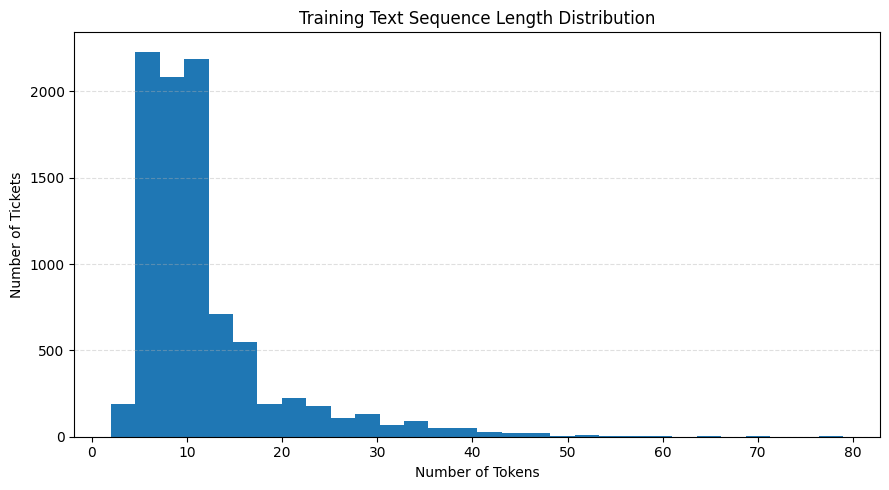

In [18]:
# Cell 16：训练集文本长度分布

import matplotlib.pyplot as plt


figure, axis = plt.subplots(
    figsize=(9, 5)
)

axis.hist(
    train_sequence_lengths,
    bins=30
)

axis.set_title(
    "Training Text Sequence Length Distribution"
)

axis.set_xlabel(
    "Number of Tokens"
)

axis.set_ylabel(
    "Number of Tickets"
)

axis.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()

In [19]:
# Cell 17：设置最大序列长度

MAX_LENGTH = 50

PAD_ID = word_to_id[PAD_TOKEN]
UNK_ID = word_to_id[UNK_TOKEN]

print("MAX_LENGTH:", MAX_LENGTH)
print("PAD_ID:", PAD_ID)
print("UNK_ID:", UNK_ID)

MAX_LENGTH: 50
PAD_ID: 0
UNK_ID: 1


## Padding / Truncation

In [20]:
# Cell 18：Padding和Truncation

def pad_or_truncate(
    token_ids,
    max_length: int,
    pad_id: int
):
    """
    将token ID序列统一到固定长度。
    """

    # 太长：截断
    if len(token_ids) > max_length:
        token_ids = token_ids[:max_length]

    # 太短：补PAD
    elif len(token_ids) < max_length:

        padding_length = (
            max_length - len(token_ids)
        )

        token_ids = (
            token_ids
            + [pad_id] * padding_length
        )

    return token_ids

In [21]:
short_example = [5, 10, 20]

processed_example = pad_or_truncate(
    short_example,
    max_length=6,
    pad_id=PAD_ID
)

print(processed_example)

[5, 10, 20, 0, 0, 0]


In [22]:
# Cell 19：完整文本编码

def encode_and_pad_text(
    text: str,
    vocabulary: dict,
    max_length: int
):

    token_ids = encode_text(
        text,
        vocabulary
    )

    token_ids = pad_or_truncate(
        token_ids,
        max_length=max_length,
        pad_id=vocabulary[PAD_TOKEN]
    )

    return token_ids

In [23]:
sample_text = (
    "My transfer has not arrived yet"
)

sample_encoded = encode_and_pad_text(
    sample_text,
    word_to_id,
    MAX_LENGTH
)

print("序列长度：", len(sample_encoded))
print(sample_encoded)

序列长度： 50
[16, 89, 92, 27, 152, 151, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


## ID映射

In [24]:
# Cell 20：建立类别ID映射

class_names = sorted(
    train_df["category"].unique()
)

label_to_id = {
    label: index
    for index, label
    in enumerate(class_names)
}

id_to_label = {
    index: label
    for label, index
    in label_to_id.items()
}

NUM_CLASSES = len(class_names)

print(
    "类别数量：",
    NUM_CLASSES
)

print()

for label in class_names[:10]:
    print(
        label,
        "→",
        label_to_id[label]
    )

类别数量： 77

Refund_not_showing_up → 0
activate_my_card → 1
age_limit → 2
apple_pay_or_google_pay → 3
atm_support → 4
automatic_top_up → 5
balance_not_updated_after_bank_transfer → 6
balance_not_updated_after_cheque_or_cash_deposit → 7
beneficiary_not_allowed → 8
cancel_transfer → 9


In [25]:
# Cell 21：确认训练/验证/测试类别一致

train_labels = set(
    train_df["category"].unique()
)

validation_labels = set(
    validation_df["category"].unique()
)

test_labels = set(
    test_df["category"].unique()
)

assert train_labels == validation_labels
assert train_labels == test_labels

print(
    "Train / Validation / Test标签完全一致。"
)

Train / Validation / Test标签完全一致。


## Dataset → DataLoader → batch

In [26]:
# Cell 22：导入Dataset和DataLoader

from torch.utils.data import Dataset, DataLoader

In [27]:
# Cell 23：定义BANKING77 Dataset

class Banking77Dataset(Dataset):

    def __init__(
        self,
        dataframe,
        vocabulary,
        label_mapping,
        max_length
    ):
        self.dataframe = (
            dataframe
            .reset_index(drop=True)
            .copy()
        )

        self.vocabulary = vocabulary
        self.label_mapping = label_mapping
        self.max_length = max_length

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):

        row = self.dataframe.iloc[index]

        text = row["text"]
        category = row["category"]

        # 文本编码
        input_ids = encode_and_pad_text(
            text=text,
            vocabulary=self.vocabulary,
            max_length=self.max_length
        )

        # 标签编码
        label_id = self.label_mapping[
            category
        ]

        # 转换成PyTorch Tensor
        input_ids = torch.tensor(
            input_ids,
            dtype=torch.long
        )

        label_id = torch.tensor(
            label_id,
            dtype=torch.long
        )

        return {
            "input_ids": input_ids,
            "label": label_id
        }

In [28]:
# Cell 24：创建Train / Validation / Test Dataset

train_dataset = Banking77Dataset(
    dataframe=train_df,
    vocabulary=word_to_id,
    label_mapping=label_to_id,
    max_length=MAX_LENGTH
)

validation_dataset = Banking77Dataset(
    dataframe=validation_df,
    vocabulary=word_to_id,
    label_mapping=label_to_id,
    max_length=MAX_LENGTH
)

test_dataset = Banking77Dataset(
    dataframe=test_df,
    vocabulary=word_to_id,
    label_mapping=label_to_id,
    max_length=MAX_LENGTH
)

print("Train dataset:", len(train_dataset))
print(
    "Validation dataset:",
    len(validation_dataset)
)
print("Test dataset:", len(test_dataset))

Train dataset: 9149
Validation dataset: 1961
Test dataset: 1961


In [29]:
# Cell 25：检查Dataset单条输出

sample = train_dataset[0]

print(
    "input_ids shape:",
    sample["input_ids"].shape
)

print(
    "label:",
    sample["label"]
)

print(
    "sequence length:",
    len(sample["input_ids"])
)

input_ids shape: torch.Size([50])
label: tensor(73)
sequence length: 50


In [30]:
sample_index = 0

print(
    "Original text:"
)

print(
    train_df.iloc[
        sample_index
    ]["text"]
)

print()

print(
    "Original category:"
)

print(
    train_df.iloc[
        sample_index
    ]["category"]
)

print()

print(
    "Encoded label:"
)

print(
    train_dataset[
        sample_index
    ]["label"].item()
)

Original text:
I want to get Visa and Mastercard

Original category:
visa_or_mastercard

Encoded label:
73


In [31]:
sample_label_id = (
    train_dataset[
        sample_index
    ]["label"].item()
)

print(
    "Decoded category:"
)

print(
    id_to_label[
        sample_label_id
    ]
)

Decoded category:
visa_or_mastercard


## Dataloader

In [32]:
# Cell 26：创建DataLoader

BATCH_SIZE = 32


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print(
    "Train batches:",
    len(train_loader)
)

print(
    "Validation batches:",
    len(validation_loader)
)

print(
    "Test batches:",
    len(test_loader)
)

Train batches: 286
Validation batches: 62
Test batches: 62


In [33]:
# Cell 27：查看一个训练batch

batch = next(
    iter(train_loader)
)

print(
    "Batch input_ids shape:",
    batch["input_ids"].shape
)

print(
    "Batch labels shape:",
    batch["label"].shape
)

Batch input_ids shape: torch.Size([32, 50])
Batch labels shape: torch.Size([32])


In [34]:
print(
    batch["input_ids"][0]
)

print()

print(
    "Label ID:",
    batch["label"][0].item()
)

print(
    "Label name:",
    id_to_label[
        batch["label"][0].item()
    ]
)

tensor([ 82,  34,   2,   5,  16, 119, 109,   4, 251,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0])

Label ID: 47
Label name: pending_cash_withdrawal


## Embedding

In [35]:
# Cell 28：建立Embedding层

import torch.nn as nn


VOCAB_SIZE = len(word_to_id)
EMBEDDING_DIM = 128


embedding_layer = nn.Embedding(
    num_embeddings=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    padding_idx=PAD_ID
)

print("Vocabulary size:", VOCAB_SIZE)
print("Embedding dimension:", EMBEDDING_DIM)
print(embedding_layer)

Vocabulary size: 1459
Embedding dimension: 128
Embedding(1459, 128, padding_idx=0)


In [36]:
# Cell 29：测试Embedding输入输出形状

batch = next(
    iter(train_loader)
)

input_ids = batch["input_ids"]

print(
    "Before embedding:",
    input_ids.shape
)

embedded = embedding_layer(
    input_ids
)

print(
    "After embedding:",
    embedded.shape
)

Before embedding: torch.Size([32, 50])
After embedding: torch.Size([32, 50, 128])


In [37]:
# Cell 30：查看某个词的Embedding向量

word = "transfer"

if word in word_to_id:

    word_id = word_to_id[word]

    word_vector = (
        embedding_layer
        .weight[word_id]
        .detach()
    )

    print("Word:", word)
    print("Word ID:", word_id)
    print("Vector shape:", word_vector.shape)

    print()
    print(word_vector[:10])

else:
    print(
        f"{word} 不在Vocabulary中"
    )

Word: transfer
Word ID: 89
Vector shape: torch.Size([128])

tensor([-2.2288, -0.0572, -1.5236,  0.6685, -0.4446, -0.7298,  1.6922,  0.6352,
        -0.5142,  1.3429])


In [38]:
# Cell 31：计算两个词Embedding的余弦相似度

import torch.nn.functional as F


def embedding_cosine_similarity(
    word_a,
    word_b,
    vocabulary,
    embedding
):

    if word_a not in vocabulary:
        raise ValueError(
            f"{word_a} 不在Vocabulary中"
        )

    if word_b not in vocabulary:
        raise ValueError(
            f"{word_b} 不在Vocabulary中"
        )

    id_a = vocabulary[word_a]
    id_b = vocabulary[word_b]

    vector_a = embedding.weight[id_a]
    vector_b = embedding.weight[id_b]

    similarity = F.cosine_similarity(
        vector_a.unsqueeze(0),
        vector_b.unsqueeze(0)
    )

    return similarity.item()

In [39]:
print(
    "transfer vs pending:",
    embedding_cosine_similarity(
        "transfer",
        "pending",
        word_to_id,
        embedding_layer
    )
)

print(
    "card vs transfer:",
    embedding_cosine_similarity(
        "card",
        "transfer",
        word_to_id,
        embedding_layer
    )
)

transfer vs pending: 0.07381104677915573
card vs transfer: 0.045140307396650314


In [40]:
# Cell 32：计算Embedding参数数量

embedding_parameter_count = (
    VOCAB_SIZE
    * EMBEDDING_DIM
)

print(
    "Embedding parameters:",
    embedding_parameter_count
)

Embedding parameters: 186752


## CNN

In [41]:
# Cell 33：TextCNN超参数

EMBEDDING_DIM = 128

NUM_FILTERS = 100

KERNEL_SIZES = [
    3,
    4,
    5
]

DROPOUT_RATE = 0.5

NUM_CLASSES = 77

print("Embedding dimension:", EMBEDDING_DIM)
print("Filters per kernel size:", NUM_FILTERS)
print("Kernel sizes:", KERNEL_SIZES)
print("Dropout:", DROPOUT_RATE)
print("Classes:", NUM_CLASSES)

Embedding dimension: 128
Filters per kernel size: 100
Kernel sizes: [3, 4, 5]
Dropout: 0.5
Classes: 77


In [42]:
# Cell 34：定义TextCNN模型

import torch
import torch.nn as nn
import torch.nn.functional as F


class TextCNN(nn.Module):

    def __init__(
        self,
        vocab_size,
        embedding_dim,
        num_classes,
        num_filters,
        kernel_sizes,
        dropout_rate,
        padding_idx
    ):
        super().__init__()

        # 1. Embedding层
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=padding_idx
        )

        # 2. 多组卷积层
        self.convolutions = nn.ModuleList([
            nn.Conv1d(
                in_channels=embedding_dim,
                out_channels=num_filters,
                kernel_size=kernel_size
            )
            for kernel_size in kernel_sizes
        ])

        # 3. Dropout
        self.dropout = nn.Dropout(
            dropout_rate
        )

        # 4. 最终分类层
        self.classifier = nn.Linear(
            num_filters * len(kernel_sizes),
            num_classes
        )

    def forward(self, input_ids):

        # [batch, sequence_length]
        embedded = self.embedding(
            input_ids
        )

        # [batch, sequence_length, embedding_dim]
        #
        # Conv1d要求：
        # [batch, channels, sequence_length]
        #
        # 所以交换维度
        embedded = embedded.permute(
            0,
            2,
            1
        )

        # 现在：
        # [batch, embedding_dim, sequence_length]

        pooled_outputs = []

        for convolution in self.convolutions:

            # 卷积
            conv_output = convolution(
                embedded
            )

            # 激活函数
            activated = F.relu(
                conv_output
            )

            # Global Max Pooling
            pooled = F.max_pool1d(
                activated,
                kernel_size=activated.shape[2]
            )

            # [batch, num_filters, 1]
            # →
            # [batch, num_filters]
            pooled = pooled.squeeze(2)

            pooled_outputs.append(
                pooled
            )

        # 拼接不同kernel size的结果
        combined = torch.cat(
            pooled_outputs,
            dim=1
        )

        # Dropout
        combined = self.dropout(
            combined
        )

        # 77类输出
        logits = self.classifier(
            combined
        )

        return logits

In [43]:
# Cell 35：创建TextCNN模型

textcnn_model = TextCNN(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    num_classes=NUM_CLASSES,
    num_filters=NUM_FILTERS,
    kernel_sizes=KERNEL_SIZES,
    dropout_rate=DROPOUT_RATE,
    padding_idx=PAD_ID
)

textcnn_model = textcnn_model.to(
    device
)

print(textcnn_model)

TextCNN(
  (embedding): Embedding(1459, 128, padding_idx=0)
  (convolutions): ModuleList(
    (0): Conv1d(128, 100, kernel_size=(3,), stride=(1,))
    (1): Conv1d(128, 100, kernel_size=(4,), stride=(1,))
    (2): Conv1d(128, 100, kernel_size=(5,), stride=(1,))
  )
  (dropout): Dropout(p=0.5, inplace=False)
  (classifier): Linear(in_features=300, out_features=77, bias=True)
)


In [44]:
# Cell 36：测试TextCNN前向传播

batch = next(
    iter(train_loader)
)

input_ids = batch[
    "input_ids"
].to(device)

labels = batch[
    "label"
].to(device)

print(
    "Input shape:",
    input_ids.shape
)

with torch.no_grad():

    logits = textcnn_model(
        input_ids
    )

print(
    "Output logits shape:",
    logits.shape
)

print(
    "Label shape:",
    labels.shape
)

Input shape: torch.Size([32, 50])
Output logits shape: torch.Size([32, 77])
Label shape: torch.Size([32])


In [45]:
# Cell 37：统计模型参数数量

total_parameters = sum(
    parameter.numel()
    for parameter
    in textcnn_model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter
    in textcnn_model.parameters()
    if parameter.requires_grad
)

print(
    "Total parameters:",
    total_parameters
)

print(
    "Trainable parameters:",
    trainable_parameters
)

Total parameters: 363829
Trainable parameters: 363829


## CrossEntropyLoss + Adam + Backpropagation

In [46]:
# Cell 38：定义损失函数和优化器

import torch.optim as optim


criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    textcnn_model.parameters(),
    lr=1e-3
)

print(criterion)
print(optimizer)

CrossEntropyLoss()
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [47]:
# Cell 39：单个batch训练测试

textcnn_model.train()

batch = next(
    iter(train_loader)
)

input_ids = batch[
    "input_ids"
].to(device)

labels = batch[
    "label"
].to(device)

# 1. 清空上一轮梯度
optimizer.zero_grad()

# 2. 前向传播
logits = textcnn_model(
    input_ids
)

# 3. 计算loss
loss = criterion(
    logits,
    labels
)

# 4. 反向传播
loss.backward()

# 5. 更新参数
optimizer.step()

print(
    "Batch loss:",
    loss.item()
)

Batch loss: 4.652533531188965


In [48]:
# Cell 40：单个epoch训练函数

def train_one_epoch(
    model,
    data_loader,
    criterion,
    optimizer,
    device
):

    model.train()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for batch in data_loader:

        input_ids = (
            batch["input_ids"]
            .to(device)
        )

        labels = (
            batch["label"]
            .to(device)
        )

        optimizer.zero_grad()

        logits = model(
            input_ids
        )

        loss = criterion(
            logits,
            labels
        )

        loss.backward()

        optimizer.step()

        total_loss += (
            loss.item()
            * input_ids.size(0)
        )

        predictions = (
            logits.argmax(dim=1)
        )

        total_correct += (
            predictions
            == labels
        ).sum().item()

        total_samples += (
            labels.size(0)
        )

    average_loss = (
        total_loss
        / total_samples
    )

    accuracy = (
        total_correct
        / total_samples
    )

    return (
        average_loss,
        accuracy
    )

In [49]:
# Cell 41：验证函数

from sklearn.metrics import f1_score


def evaluate_model(
    model,
    data_loader,
    criterion,
    device
):

    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    all_predictions = []
    all_labels = []

    with torch.no_grad():

        for batch in data_loader:

            input_ids = (
                batch["input_ids"]
                .to(device)
            )

            labels = (
                batch["label"]
                .to(device)
            )

            logits = model(
                input_ids
            )

            loss = criterion(
                logits,
                labels
            )

            total_loss += (
                loss.item()
                * input_ids.size(0)
            )

            predictions = (
                logits.argmax(dim=1)
            )

            total_correct += (
                predictions
                == labels
            ).sum().item()

            total_samples += (
                labels.size(0)
            )

            all_predictions.extend(
                predictions
                .cpu()
                .numpy()
            )

            all_labels.extend(
                labels
                .cpu()
                .numpy()
            )

    average_loss = (
        total_loss
        / total_samples
    )

    accuracy = (
        total_correct
        / total_samples
    )

    macro_f1 = f1_score(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0
    )

    return (
        average_loss,
        accuracy,
        macro_f1
    )

In [50]:
# Cell 42：正式训练TextCNN

EPOCHS = 10

best_validation_f1 = -1.0

training_history = []


for epoch in range(
    1,
    EPOCHS + 1
):

    train_loss, train_accuracy = (
        train_one_epoch(
            model=textcnn_model,
            data_loader=train_loader,
            criterion=criterion,
            optimizer=optimizer,
            device=device
        )
    )

    (
        validation_loss,
        validation_accuracy,
        validation_macro_f1
    ) = evaluate_model(
        model=textcnn_model,
        data_loader=validation_loader,
        criterion=criterion,
        device=device
    )

    training_history.append(
        {
            "epoch": epoch,
            "train_loss": train_loss,
            "train_accuracy": train_accuracy,
            "validation_loss": validation_loss,
            "validation_accuracy": validation_accuracy,
            "validation_macro_f1": validation_macro_f1
        }
    )

    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {validation_loss:.4f} | "
        f"Val Acc: {validation_accuracy:.4f} | "
        f"Val Macro-F1: {validation_macro_f1:.4f}"
    )

    if (
        validation_macro_f1
        > best_validation_f1
    ):

        best_validation_f1 = (
            validation_macro_f1
        )

        torch.save(
            textcnn_model.state_dict(),
            "best_textcnn.pt"
        )

        print(
            "  → Best model updated"
        )

Epoch 01 | Train Loss: 2.8633 | Train Acc: 0.3285 | Val Loss: 1.4198 | Val Acc: 0.6655 | Val Macro-F1: 0.6577
  → Best model updated
Epoch 02 | Train Loss: 1.2536 | Train Acc: 0.6719 | Val Loss: 0.8763 | Val Acc: 0.7899 | Val Macro-F1: 0.7889
  → Best model updated
Epoch 03 | Train Loss: 0.8249 | Train Acc: 0.7706 | Val Loss: 0.6864 | Val Acc: 0.8368 | Val Macro-F1: 0.8358
  → Best model updated
Epoch 04 | Train Loss: 0.6023 | Train Acc: 0.8336 | Val Loss: 0.5944 | Val Acc: 0.8531 | Val Macro-F1: 0.8544
  → Best model updated
Epoch 05 | Train Loss: 0.4579 | Train Acc: 0.8698 | Val Loss: 0.5606 | Val Acc: 0.8542 | Val Macro-F1: 0.8550
  → Best model updated
Epoch 06 | Train Loss: 0.3706 | Train Acc: 0.8939 | Val Loss: 0.5085 | Val Acc: 0.8649 | Val Macro-F1: 0.8651
  → Best model updated
Epoch 07 | Train Loss: 0.2999 | Train Acc: 0.9156 | Val Loss: 0.5068 | Val Acc: 0.8649 | Val Macro-F1: 0.8656
  → Best model updated
Epoch 08 | Train Loss: 0.2445 | Train Acc: 0.9306 | Val Loss: 0.4740 

In [51]:
# Cell 43：加载验证集Macro-F1最好的模型

textcnn_model.load_state_dict(
    torch.load(
        "best_textcnn.pt",
        map_location=device
    )
)

textcnn_model = (
    textcnn_model.to(device)
)

print(
    "Best validation Macro-F1:",
    best_validation_f1
)

Best validation Macro-F1: 0.8735026663126181


## Early Stopping

In [52]:
# Cell 44：重新初始化TextCNN进行Early Stopping实验

textcnn_model = TextCNN(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    num_classes=NUM_CLASSES,
    num_filters=NUM_FILTERS,
    kernel_sizes=KERNEL_SIZES,
    dropout_rate=DROPOUT_RATE,
    padding_idx=PAD_ID
).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    textcnn_model.parameters(),
    lr=1e-3
)

MAX_EPOCHS = 25
PATIENCE = 4

best_validation_f1 = -1.0
epochs_without_improvement = 0

training_history = []

In [53]:

# Cell 45：带Early Stopping的训练

for epoch in range(1, MAX_EPOCHS + 1):

    train_loss, train_accuracy = train_one_epoch(
        model=textcnn_model,
        data_loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device
    )

    (
        validation_loss,
        validation_accuracy,
        validation_macro_f1
    ) = evaluate_model(
        model=textcnn_model,
        data_loader=validation_loader,
        criterion=criterion,
        device=device
    )

    training_history.append(
        {
            "epoch": epoch,
            "train_loss": train_loss,
            "train_accuracy": train_accuracy,
            "validation_loss": validation_loss,
            "validation_accuracy": validation_accuracy,
            "validation_macro_f1": validation_macro_f1
        }
    )

    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {validation_loss:.4f} | "
        f"Val Acc: {validation_accuracy:.4f} | "
        f"Val Macro-F1: {validation_macro_f1:.4f}"
    )

    if validation_macro_f1 > best_validation_f1:

        best_validation_f1 = validation_macro_f1
        epochs_without_improvement = 0

        torch.save(
            textcnn_model.state_dict(),
            "best_textcnn.pt"
        )

        print("  → Best model updated")

    else:

        epochs_without_improvement += 1

        print(
            f"  → No improvement "
            f"({epochs_without_improvement}/{PATIENCE})"
        )

        if epochs_without_improvement >= PATIENCE:

            print("Early stopping triggered.")
            break

Epoch 01 | Train Loss: 2.9025 | Train Acc: 0.3280 | Val Loss: 1.4418 | Val Acc: 0.6762 | Val Macro-F1: 0.6763
  → Best model updated
Epoch 02 | Train Loss: 1.2665 | Train Acc: 0.6664 | Val Loss: 0.8819 | Val Acc: 0.7787 | Val Macro-F1: 0.7811
  → Best model updated
Epoch 03 | Train Loss: 0.8288 | Train Acc: 0.7718 | Val Loss: 0.6831 | Val Acc: 0.8281 | Val Macro-F1: 0.8297
  → Best model updated
Epoch 04 | Train Loss: 0.5969 | Train Acc: 0.8340 | Val Loss: 0.5813 | Val Acc: 0.8414 | Val Macro-F1: 0.8431
  → Best model updated
Epoch 05 | Train Loss: 0.4711 | Train Acc: 0.8672 | Val Loss: 0.5263 | Val Acc: 0.8552 | Val Macro-F1: 0.8570
  → Best model updated
Epoch 06 | Train Loss: 0.3613 | Train Acc: 0.8985 | Val Loss: 0.4904 | Val Acc: 0.8669 | Val Macro-F1: 0.8680
  → Best model updated
Epoch 07 | Train Loss: 0.2947 | Train Acc: 0.9166 | Val Loss: 0.4587 | Val Acc: 0.8669 | Val Macro-F1: 0.8674
  → No improvement (1/4)
Epoch 08 | Train Loss: 0.2471 | Train Acc: 0.9321 | Val Loss: 0.441

In [54]:
textcnn_model.load_state_dict(
    torch.load(
        "best_textcnn.pt",
        map_location=device
    )
)

print(
    "Best validation Macro-F1:",
    best_validation_f1
)

Best validation Macro-F1: 0.8926005048446123


In [55]:
# Cell 46：加载最佳TextCNN

textcnn_model.load_state_dict(
    torch.load(
        "best_textcnn.pt",
        map_location=device
    )
)

textcnn_model = textcnn_model.to(device)

In [56]:
# Cell 47：最终测试集评估

(
    test_loss,
    test_accuracy,
    test_macro_f1
) = evaluate_model(
    model=textcnn_model,
    data_loader=test_loader,
    criterion=criterion,
    device=device
)

print(
    "TextCNN Test Loss:",
    f"{test_loss:.4f}"
)

print(
    "TextCNN Test Accuracy:",
    f"{test_accuracy:.4f}"
)

print(
    "TextCNN Test Macro-F1:",
    f"{test_macro_f1:.4f}"
)

TextCNN Test Loss: 0.5029
TextCNN Test Accuracy: 0.8822
TextCNN Test Macro-F1: 0.8843


## Compare SVM AND CNN

In [57]:
# Cell 48：获取TextCNN验证集预测

textcnn_model.eval()

textcnn_validation_predictions = []
textcnn_validation_labels = []
textcnn_validation_probs = []

with torch.no_grad():

    for batch in validation_loader:

        input_ids = batch["input_ids"].to(device)
        labels = batch["label"].to(device)

        logits = textcnn_model(input_ids)

        probabilities = torch.softmax(
            logits,
            dim=1
        )

        predictions = logits.argmax(
            dim=1
        )

        textcnn_validation_predictions.extend(
            predictions.cpu().numpy()
        )

        textcnn_validation_labels.extend(
            labels.cpu().numpy()
        )

        textcnn_validation_probs.extend(
            probabilities.cpu().numpy()
        )

textcnn_validation_predictions = np.array(
    textcnn_validation_predictions
)

textcnn_validation_labels = np.array(
    textcnn_validation_labels
)

textcnn_validation_probs = np.array(
    textcnn_validation_probs
)

print(
    "Validation predictions:",
    len(textcnn_validation_predictions)
)

Validation predictions: 1961


In [58]:
# Cell 49：类别ID → 类别名称

textcnn_predicted_labels = [
    id_to_label[int(label_id)]
    for label_id
    in textcnn_validation_predictions
]

true_validation_labels = [
    id_to_label[int(label_id)]
    for label_id
    in textcnn_validation_labels
]

In [59]:
print(
    true_validation_labels[:5]
)

print(
    textcnn_predicted_labels[:5]
)

['wrong_amount_of_cash_received', 'supported_cards_and_currencies', 'declined_cash_withdrawal', 'beneficiary_not_allowed', 'getting_spare_card']
['wrong_amount_of_cash_received', 'supported_cards_and_currencies', 'declined_cash_withdrawal', 'beneficiary_not_allowed', 'getting_spare_card']


In [60]:
# Cell 50：TextCNN验证集错误分析

textcnn_error_df = pd.DataFrame({
    "text": validation_df["text"].reset_index(drop=True),
    "true_category": true_validation_labels,
    "predicted_category": textcnn_predicted_labels
})

textcnn_error_df["is_correct"] = (
    textcnn_error_df["true_category"]
    == textcnn_error_df["predicted_category"]
)

print(
    "Validation Accuracy:",
    textcnn_error_df["is_correct"].mean()
)

print(
    "错误数量:",
    (~textcnn_error_df["is_correct"]).sum()
)

Validation Accuracy: 0.8918918918918919
错误数量: 212


In [61]:
# Cell 51：TextCNN Top confusion pairs

textcnn_wrong_df = (
    textcnn_error_df[
        ~textcnn_error_df["is_correct"]
    ]
    .copy()
)

textcnn_confusion_pairs_df = (
    textcnn_wrong_df
    .groupby(
        [
            "true_category",
            "predicted_category"
        ]
    )
    .size()
    .reset_index(
        name="error_count"
    )
    .sort_values(
        by="error_count",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    textcnn_confusion_pairs_df.head(20)
)

,true_category,predicted_category,error_count
0,card_not_working,declined_card_payment,3
1,card_delivery_estimate,country_support,3
2,transfer_fee_charged,top_up_by_bank_transfer_charge,3
3,unable_to_verify_identity,why_verify_identity,3
4,exchange_charge,exchange_via_app,3
5,get_disposable_virtual_card,getting_virtual_card,3
6,declined_transfer,failed_transfer,3
7,transfer_fee_charged,card_payment_fee_charged,3
8,transfer_timing,transfer_not_received_by_recipient,3
9,transfer_not_received_by_recipient,balance_not_updated_after_bank_transfer,3


In [62]:
# Cell 52：TextCNN每类别指标

from sklearn.metrics import classification_report

textcnn_report = classification_report(
    true_validation_labels,
    textcnn_predicted_labels,
    output_dict=True,
    zero_division=0
)

textcnn_report_df = (
    pd.DataFrame(textcnn_report)
    .transpose()
)

textcnn_per_class_df = (
    textcnn_report_df
    .loc[class_names]
    .copy()
)

textcnn_lowest_recall_df = (
    textcnn_per_class_df
    .sort_values(
        by="recall",
        ascending=True
    )
    .head(15)
)

display(
    textcnn_lowest_recall_df[
        [
            "precision",
            "recall",
            "f1-score",
            "support"
        ]
    ]
)

,precision,recall,f1-score,support
card_not_working,1.000000,0.681818,0.810811,22.0
lost_or_stolen_card,0.928571,0.684211,0.787879,19.0
exchange_charge,0.944444,0.708333,0.809524,24.0
transfer_timing,1.000000,0.720000,0.837209,25.0
declined_transfer,0.791667,0.730769,0.760000,26.0
card_delivery_estimate,0.809524,0.739130,0.772727,23.0
transfer_not_received_by_recipient,0.766667,0.741935,0.754098,31.0
transfer_fee_charged,0.923077,0.750000,0.827586,32.0
compromised_card,0.681818,0.789474,0.731707,19.0
order_physical_card,0.791667,0.791667,0.791667,24.0


In [63]:
# Cell 53：加载TF-IDF + SVM

import joblib

SVM_MODEL_DIR = (
    PROJECT_ROOT
    / "models"
    / "ml_baseline"
)

loaded_tfidf = joblib.load(
    SVM_MODEL_DIR
    / "tfidf_vectorizer.joblib"
)

loaded_svm = joblib.load(
    SVM_MODEL_DIR
    / "linear_svm_c1.joblib"
)

print("SVM loaded.")

SVM loaded.


In [64]:
# Cell 54：SVM验证集预测

svm_validation_features = (
    loaded_tfidf.transform(
        validation_df["text"]
    )
)

svm_validation_predictions = (
    loaded_svm.predict(
        svm_validation_features
    )
)

print(
    "SVM validation predictions:",
    len(svm_validation_predictions)
)

SVM validation predictions: 1961


In [65]:
# Cell 55：逐样本比较SVM与TextCNN

model_comparison_df = pd.DataFrame({
    "text": validation_df["text"].reset_index(drop=True),

    "true_category":
        validation_df["category"].reset_index(drop=True),

    "svm_prediction":
        svm_validation_predictions,

    "textcnn_prediction":
        textcnn_predicted_labels
})


model_comparison_df["svm_correct"] = (
    model_comparison_df["svm_prediction"]
    == model_comparison_df["true_category"]
)

model_comparison_df["textcnn_correct"] = (
    model_comparison_df["textcnn_prediction"]
    == model_comparison_df["true_category"]
)

In [66]:
def compare_result(row):

    if (
        row["svm_correct"]
        and row["textcnn_correct"]
    ):
        return "both_correct"

    elif (
        not row["svm_correct"]
        and row["textcnn_correct"]
    ):
        return "textcnn_fixed_svm_error"

    elif (
        row["svm_correct"]
        and not row["textcnn_correct"]
    ):
        return "textcnn_new_error"

    else:
        return "both_wrong"


model_comparison_df["comparison"] = (
    model_comparison_df.apply(
        compare_result,
        axis=1
    )
)

display(
    model_comparison_df[
        "comparison"
    ].value_counts()
)

comparison
both_correct               1663
both_wrong                  129
textcnn_fixed_svm_error      86
textcnn_new_error            83
Name: count, dtype: int64

In [67]:
# Cell 56：SVM错但TextCNN正确

textcnn_fixed_errors_df = (
    model_comparison_df[
        model_comparison_df["comparison"]
        == "textcnn_fixed_svm_error"
    ]
    .copy()
)

display(
    textcnn_fixed_errors_df[
        [
            "text",
            "true_category",
            "svm_prediction",
            "textcnn_prediction"
        ]
    ]
    .head(30)
)

,text,true_category,svm_prediction,textcnn_prediction
2,I want to know why I have been unable to withd...,declined_cash_withdrawal,beneficiary_not_allowed,declined_cash_withdrawal
12,I am having problems with my physical card.,card_not_working,top_up_failed,card_not_working
60,"I need an accurate exchange rate, when I make ...",wrong_exchange_rate_for_cash_withdrawal,exchange_rate,wrong_exchange_rate_for_cash_withdrawal
90,Why hasn't my money transfer shown up yet?,balance_not_updated_after_bank_transfer,pending_transfer,balance_not_updated_after_bank_transfer
92,What is this charge on my account for a cash w...,cash_withdrawal_charge,cash_withdrawal_not_recognised,cash_withdrawal_charge
96,I think there has been a mistake with my transfer,declined_transfer,cancel_transfer,declined_transfer
100,I left my card at a restaurant and now its mis...,lost_or_stolen_card,card_not_working,lost_or_stolen_card
104,Still waiting for transfer to be completed.,transfer_not_received_by_recipient,pending_transfer,transfer_not_received_by_recipient
138,i need a refund from you because the merchant ...,Refund_not_showing_up,request_refund,Refund_not_showing_up
180,My ATM transaction was unsuccessful.,declined_cash_withdrawal,failed_transfer,declined_cash_withdrawal


In [68]:
# Cell 57：SVM正确但TextCNN错误

textcnn_new_errors_df = (
    model_comparison_df[
        model_comparison_df["comparison"]
        == "textcnn_new_error"
    ]
    .copy()
)

display(
    textcnn_new_errors_df[
        [
            "text",
            "true_category",
            "svm_prediction",
            "textcnn_prediction"
        ]
    ]
    .head(30)
)

,text,true_category,svm_prediction,textcnn_prediction
7,My card was declined today when eating and I n...,card_not_working,card_not_working,declined_card_payment
15,Why is the fee for taking money out so high? ...,wrong_exchange_rate_for_cash_withdrawal,wrong_exchange_rate_for_cash_withdrawal,cash_withdrawal_charge
27,Why is my exchange rate wrong?,card_payment_wrong_exchange_rate,card_payment_wrong_exchange_rate,wrong_exchange_rate_for_cash_withdrawal
85,Can you tell me what I need to do to have my p...,change_pin,change_pin,pin_blocked
103,My exchange rate isn't correct.,card_payment_wrong_exchange_rate,card_payment_wrong_exchange_rate,wrong_exchange_rate_for_cash_withdrawal
224,"I froze my account, but how do I order a repla...",compromised_card,compromised_card,getting_spare_card
245,"I need to order a new virtual card, how do I d...",getting_virtual_card,getting_virtual_card,get_disposable_virtual_card
334,I tired to deposit some cash into my account b...,balance_not_updated_after_cheque_or_cash_deposit,balance_not_updated_after_cheque_or_cash_deposit,top_up_by_cash_or_cheque
339,The receipient doesn't see my money transfer.,transfer_not_received_by_recipient,transfer_not_received_by_recipient,balance_not_updated_after_bank_transfer
345,disposable virtual card can be ordered where?,get_disposable_virtual_card,get_disposable_virtual_card,getting_virtual_card


In [69]:
# Cell 58：统计TextCNN相对SVM的错误净变化

fixed_count = len(
    textcnn_fixed_errors_df
)

new_error_count = len(
    textcnn_new_errors_df
)

net_improvement = (
    fixed_count
    - new_error_count
)

print(
    "TextCNN修复的SVM错误：",
    fixed_count
)

print(
    "TextCNN新增错误：",
    new_error_count
)

print(
    "净减少错误数量：",
    net_improvement
)

TextCNN修复的SVM错误： 86
TextCNN新增错误： 83
净减少错误数量： 3


## Compare the correctness between Textcnn and SVM

In [70]:
# Cell 59：统计TextCNN修复的SVM错误，按真实类别分组

fixed_by_class_df = (
    textcnn_fixed_errors_df
    .groupby("true_category")
    .size()
    .reset_index(name="fixed_count")
    .sort_values(
        by="fixed_count",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    fixed_by_class_df.head(20)
)

,true_category,fixed_count
0,declined_cash_withdrawal,5
1,wrong_amount_of_cash_received,5
2,virtual_card_not_working,4
3,card_payment_fee_charged,3
4,balance_not_updated_after_bank_transfer,3
5,pending_top_up,3
6,fiat_currency_support,3
7,declined_card_payment,3
8,pending_cash_withdrawal,3
9,wrong_exchange_rate_for_cash_withdrawal,3


In [71]:
# Cell 60：统计TextCNN新增错误，按真实类别分组

new_errors_by_class_df = (
    textcnn_new_errors_df
    .groupby("true_category")
    .size()
    .reset_index(name="new_error_count")
    .sort_values(
        by="new_error_count",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    new_errors_by_class_df.head(20)
)

,true_category,new_error_count
0,cash_withdrawal_not_recognised,4
1,exchange_charge,4
2,request_refund,3
3,top_up_failed,3
4,wrong_exchange_rate_for_cash_withdrawal,3
5,transfer_not_received_by_recipient,3
6,order_physical_card,3
7,balance_not_updated_after_cheque_or_cash_deposit,3
8,country_support,2
9,change_pin,2


In [72]:
# Cell 61：计算每个类别的净收益

class_gain_df = pd.DataFrame({
    "true_category": class_names
})

class_gain_df = class_gain_df.merge(
    fixed_by_class_df,
    on="true_category",
    how="left"
)

class_gain_df = class_gain_df.merge(
    new_errors_by_class_df,
    on="true_category",
    how="left"
)

class_gain_df[
    ["fixed_count", "new_error_count"]
] = (
    class_gain_df[
        ["fixed_count", "new_error_count"]
    ]
    .fillna(0)
    .astype(int)
)

class_gain_df["net_gain"] = (
    class_gain_df["fixed_count"]
    - class_gain_df["new_error_count"]
)

display(
    class_gain_df.sort_values(
        by="net_gain",
        ascending=False
    ).head(20)
)

,true_category,fixed_count,new_error_count,net_gain
27,declined_cash_withdrawal,5,0,5
72,virtual_card_not_working,4,0,4
37,fiat_currency_support,3,0,3
16,card_payment_fee_charged,3,0,3
75,wrong_amount_of_cash_received,5,2,3
26,declined_card_payment,3,1,2
20,cash_withdrawal_charge,2,0,2
48,pending_top_up,3,1,2
6,balance_not_updated_after_bank_transfer,3,1,2
56,top_up_by_bank_transfer_charge,2,0,2


In [73]:
# Cell 62：TextCNN净收益最大的类别

most_improved_classes_df = (
    class_gain_df
    .sort_values(
        by="net_gain",
        ascending=False
    )
    .head(15)
)

display(most_improved_classes_df)

,true_category,fixed_count,new_error_count,net_gain
27,declined_cash_withdrawal,5,0,5
72,virtual_card_not_working,4,0,4
37,fiat_currency_support,3,0,3
16,card_payment_fee_charged,3,0,3
75,wrong_amount_of_cash_received,5,2,3
26,declined_card_payment,3,1,2
20,cash_withdrawal_charge,2,0,2
48,pending_top_up,3,1,2
6,balance_not_updated_after_bank_transfer,3,1,2
56,top_up_by_bank_transfer_charge,2,0,2


In [74]:
# Cell 63：TextCNN净退步最大的类别

most_degraded_classes_df = (
    class_gain_df
    .sort_values(
        by="net_gain",
        ascending=True
    )
    .head(15)
)

display(most_degraded_classes_df)

,true_category,fixed_count,new_error_count,net_gain
21,cash_withdrawal_not_recognised,0,4,-4
32,exchange_charge,0,4,-4
52,request_refund,0,3,-3
7,balance_not_updated_after_cheque_or_cash_deposit,0,3,-3
25,country_support,0,2,-2
46,pending_card_payment,0,2,-2
22,change_pin,0,2,-2
9,cancel_transfer,0,2,-2
38,get_disposable_virtual_card,0,2,-2
58,top_up_by_cash_or_cheque,0,2,-2


In [75]:
# Cell 64：计算SVM每类别指标

svm_report = classification_report(
    validation_df["category"],
    svm_validation_predictions,
    output_dict=True,
    zero_division=0
)

svm_report_df = (
    pd.DataFrame(svm_report)
    .transpose()
)

svm_per_class_df = (
    svm_report_df
    .loc[class_names]
    .copy()
)

In [76]:
# Cell 65：逐类别比较SVM和TextCNN

per_class_comparison_df = pd.DataFrame({
    "category": class_names,

    "svm_precision":
        svm_per_class_df["precision"].values,

    "svm_recall":
        svm_per_class_df["recall"].values,

    "svm_f1":
        svm_per_class_df["f1-score"].values,

    "textcnn_precision":
        textcnn_per_class_df["precision"].values,

    "textcnn_recall":
        textcnn_per_class_df["recall"].values,

    "textcnn_f1":
        textcnn_per_class_df["f1-score"].values,

    "support":
        textcnn_per_class_df["support"].values
})

per_class_comparison_df["f1_change"] = (
    per_class_comparison_df["textcnn_f1"]
    - per_class_comparison_df["svm_f1"]
)

per_class_comparison_df["recall_change"] = (
    per_class_comparison_df["textcnn_recall"]
    - per_class_comparison_df["svm_recall"]
)

In [77]:
# Cell 66：F1提升最大类别

display(
    per_class_comparison_df
    .sort_values(
        by="f1_change",
        ascending=False
    )
    .head(15)
)

,category,svm_precision,svm_recall,svm_f1,textcnn_precision,textcnn_recall,textcnn_f1,support,f1_change,recall_change
72,virtual_card_not_working,0.700000,0.583333,0.636364,1.000000,0.916667,0.956522,12.0,0.320158,0.333333
70,verify_source_of_funds,0.800000,0.869565,0.833333,0.954545,0.913043,0.933333,23.0,0.100000,0.043478
37,fiat_currency_support,0.869565,0.800000,0.833333,0.920000,0.920000,0.920000,25.0,0.086667,0.120000
54,supported_cards_and_currencies,0.777778,0.840000,0.807692,0.851852,0.920000,0.884615,25.0,0.076923,0.080000
27,declined_cash_withdrawal,0.862069,0.781250,0.819672,0.857143,0.937500,0.895522,32.0,0.075850,0.156250
11,card_acceptance,0.866667,0.928571,0.896552,0.933333,1.000000,0.965517,14.0,0.068966,0.071429
56,top_up_by_bank_transfer_charge,0.833333,0.869565,0.851064,0.880000,0.956522,0.916667,23.0,0.065603,0.086957
61,top_up_reverted,0.806452,0.892857,0.847458,0.925926,0.892857,0.909091,28.0,0.061633,0.000000
65,transfer_into_account,0.800000,0.869565,0.833333,0.875000,0.913043,0.893617,23.0,0.060284,0.043478
67,transfer_timing,0.826087,0.760000,0.791667,1.000000,0.720000,0.837209,25.0,0.045543,-0.040000


In [78]:
# Cell 67：F1下降最大类别

display(
    per_class_comparison_df
    .sort_values(
        by="f1_change",
        ascending=True
    )
    .head(15)
)

,category,svm_precision,svm_recall,svm_f1,textcnn_precision,textcnn_recall,textcnn_f1,support,f1_change,recall_change
66,transfer_not_received_by_recipient,0.862069,0.806452,0.833333,0.766667,0.741935,0.754098,31.0,-0.079235,-0.064516
76,wrong_exchange_rate_for_cash_withdrawal,0.961538,0.833333,0.892857,0.806452,0.833333,0.819672,30.0,-0.073185,0.000000
58,top_up_by_cash_or_cheque,0.913043,0.913043,0.913043,0.863636,0.826087,0.844444,23.0,-0.068599,-0.086957
25,country_support,0.880000,0.880000,0.880000,0.833333,0.800000,0.816327,25.0,-0.063673,-0.080000
18,card_payment_wrong_exchange_rate,0.965517,0.903226,0.933333,0.870968,0.870968,0.870968,31.0,-0.062366,-0.032258
21,cash_withdrawal_not_recognised,0.857143,1.000000,0.923077,0.866667,0.866667,0.866667,30.0,-0.056410,-0.133333
52,request_refund,0.937500,0.967742,0.952381,0.931034,0.870968,0.900000,31.0,-0.052381,-0.096774
51,receiving_money,0.904762,0.950000,0.926829,0.857143,0.900000,0.878049,20.0,-0.048780,-0.050000
32,exchange_charge,0.840000,0.875000,0.857143,0.944444,0.708333,0.809524,24.0,-0.047619,-0.166667
17,card_payment_not_recognised,0.937500,0.967742,0.952381,0.878788,0.935484,0.906250,31.0,-0.046131,-0.032258


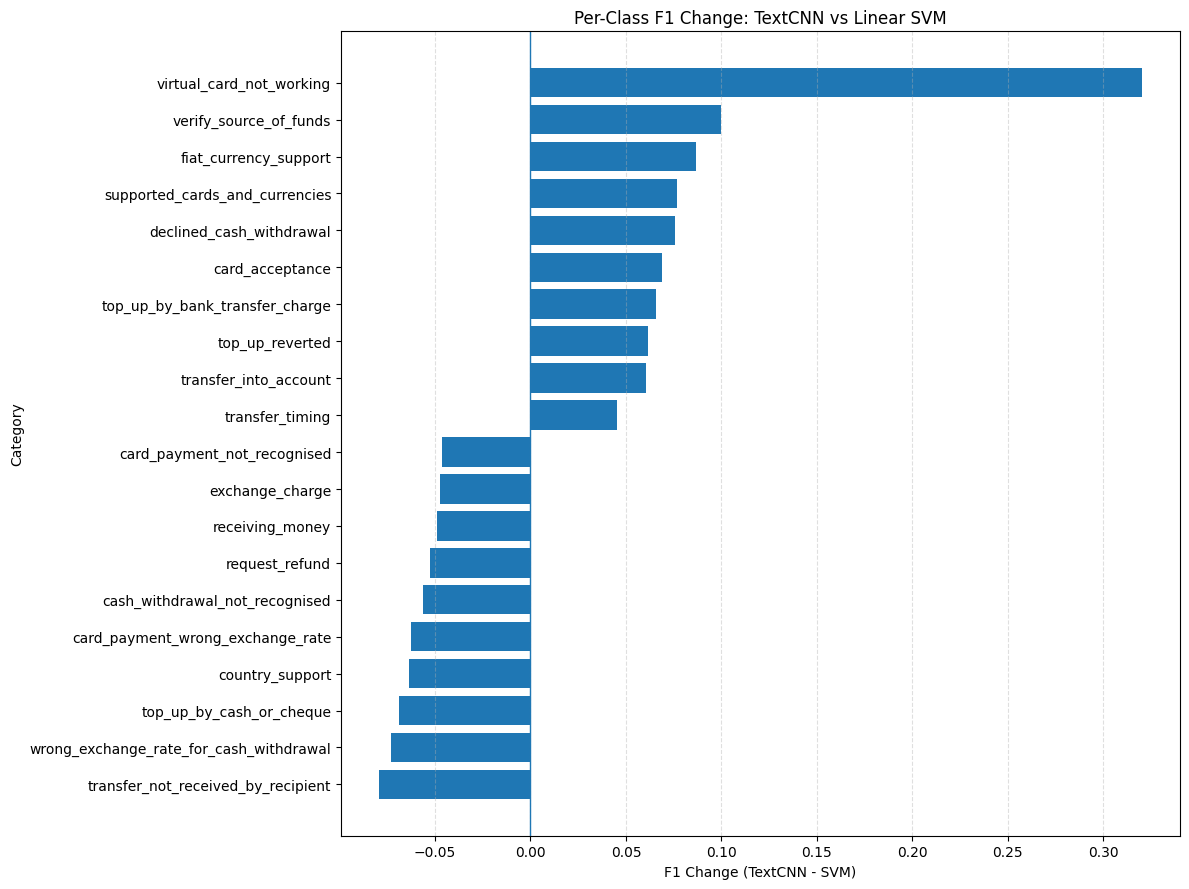

In [79]:
# Cell 68：可视化F1变化最大的类别

top_changes_df = pd.concat([
    per_class_comparison_df
    .nlargest(10, "f1_change"),

    per_class_comparison_df
    .nsmallest(10, "f1_change")
])

top_changes_df = (
    top_changes_df
    .sort_values("f1_change")
)

figure, axis = plt.subplots(
    figsize=(12, 9)
)

axis.barh(
    top_changes_df["category"],
    top_changes_df["f1_change"]
)

axis.axvline(
    0,
    linewidth=1
)

axis.set_title(
    "Per-Class F1 Change: TextCNN vs Linear SVM"
)

axis.set_xlabel(
    "F1 Change (TextCNN - SVM)"
)

axis.set_ylabel(
    "Category"
)

axis.grid(
    axis="x",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()

TextCNN 并不是全面优于 SVM，而是更擅长依赖局部词组和状态组合的类别；SVM 则在关键词高度判别性的类别上依然具有优势。

## virtual_card_not_working class

In [80]:
# Cell 69：查看virtual_card_not_working的模型对比

improved_category = "virtual_card_not_working"

improved_examples_df = (
    model_comparison_df[
        model_comparison_df["true_category"]
        == improved_category
    ]
    .copy()
)

display(
    improved_examples_df[
        [
            "text",
            "true_category",
            "svm_prediction",
            "textcnn_prediction",
            "svm_correct",
            "textcnn_correct"
        ]
    ]
)

,text,true_category,svm_prediction,textcnn_prediction,svm_correct,textcnn_correct
144,Why is my disposable virtual card being denied?,virtual_card_not_working,virtual_card_not_working,virtual_card_not_working,True,True
243,My disposable virtual card doesn't seem to work,virtual_card_not_working,virtual_card_not_working,virtual_card_not_working,True,True
377,My disposable virtual card is broken.,virtual_card_not_working,get_disposable_virtual_card,virtual_card_not_working,False,True
726,How do I get my disposable virtual card to work?,virtual_card_not_working,get_disposable_virtual_card,virtual_card_not_working,False,True
999,My disposable virtual card won't work.,virtual_card_not_working,virtual_card_not_working,virtual_card_not_working,True,True
1283,Are there restrictions for my disposable card ...,virtual_card_not_working,disposable_card_limits,virtual_card_not_working,False,True
1326,I can't make purchases with my virtual card.,virtual_card_not_working,virtual_card_not_working,virtual_card_not_working,True,True
1513,"For some reason, the virtual card won't work f...",virtual_card_not_working,virtual_card_not_working,virtual_card_not_working,True,True
1527,The virtual card won't work.,virtual_card_not_working,virtual_card_not_working,virtual_card_not_working,True,True
1613,My disposable virtual card isn't working.,virtual_card_not_working,virtual_card_not_working,virtual_card_not_working,True,True


In [81]:
# Cell 70：TextCNN修复的virtual_card_not_working样本

improved_fixed_df = (
    improved_examples_df[
        (~improved_examples_df["svm_correct"])
        &
        (improved_examples_df["textcnn_correct"])
    ]
    .copy()
)

print(
    "TextCNN修复数量：",
    len(improved_fixed_df)
)

display(
    improved_fixed_df[
        [
            "text",
            "svm_prediction",
            "textcnn_prediction"
        ]
    ]
)

TextCNN修复数量： 4


,text,svm_prediction,textcnn_prediction
377,My disposable virtual card is broken.,get_disposable_virtual_card,virtual_card_not_working
726,How do I get my disposable virtual card to work?,get_disposable_virtual_card,virtual_card_not_working
1283,Are there restrictions for my disposable card ...,disposable_card_limits,virtual_card_not_working
1782,My transaction was just declined when I was us...,get_disposable_virtual_card,virtual_card_not_working


In [82]:
# Cell 71：查看transfer_not_received_by_recipient

degraded_category = (
    "transfer_not_received_by_recipient"
)

degraded_examples_df = (
    model_comparison_df[
        model_comparison_df["true_category"]
        == degraded_category
    ]
    .copy()
)

display(
    degraded_examples_df[
        [
            "text",
            "true_category",
            "svm_prediction",
            "textcnn_prediction",
            "svm_correct",
            "textcnn_correct"
        ]
    ]
)

,text,true_category,svm_prediction,textcnn_prediction,svm_correct,textcnn_correct
104,Still waiting for transfer to be completed.,transfer_not_received_by_recipient,pending_transfer,transfer_not_received_by_recipient,False,True
124,I transferred money and it hasn't come yet,transfer_not_received_by_recipient,balance_not_updated_after_bank_transfer,balance_not_updated_after_bank_transfer,False,False
216,Where is the transaction I made to a friend?,transfer_not_received_by_recipient,transfer_not_received_by_recipient,transfer_not_received_by_recipient,True,True
339,The receipient doesn't see my money transfer.,transfer_not_received_by_recipient,transfer_not_received_by_recipient,balance_not_updated_after_bank_transfer,True,False
385,My friend still hasn't gotten a transaction I ...,transfer_not_received_by_recipient,transfer_not_received_by_recipient,transfer_not_received_by_recipient,True,True
468,How long do transfers typically take? Is there...,transfer_not_received_by_recipient,transfer_not_received_by_recipient,transfer_not_received_by_recipient,True,True
478,Recipient has not received the money,transfer_not_received_by_recipient,transfer_not_received_by_recipient,transfer_not_received_by_recipient,True,True
527,|I moved out of my old house two weeks ago and...,transfer_not_received_by_recipient,direct_debit_payment_not_recognised,direct_debit_payment_not_recognised,False,False
546,Why is my transaction taking so long to complete?,transfer_not_received_by_recipient,transfer_not_received_by_recipient,transfer_not_received_by_recipient,True,True
569,i've waited 2 days for a transfer to reach a r...,transfer_not_received_by_recipient,transfer_timing,pending_transfer,False,False


In [83]:
# Cell 72：TextCNN新增错误

degraded_new_errors_df = (
    degraded_examples_df[
        (degraded_examples_df["svm_correct"])
        &
        (~degraded_examples_df["textcnn_correct"])
    ]
    .copy()
)

print(
    "TextCNN新增错误数量：",
    len(degraded_new_errors_df)
)

display(
    degraded_new_errors_df[
        [
            "text",
            "svm_prediction",
            "textcnn_prediction"
        ]
    ]
)

TextCNN新增错误数量： 3


,text,svm_prediction,textcnn_prediction
339,The receipient doesn't see my money transfer.,transfer_not_received_by_recipient,balance_not_updated_after_bank_transfer
1781,I transferred some money and it didint arrive,transfer_not_received_by_recipient,balance_not_updated_after_bank_transfer
1929,Why has my transfer not arrived yet?,transfer_not_received_by_recipient,pending_transfer


In [84]:
# Cell 73：TextCNN错误去向统计

degraded_prediction_counts_df = (
    degraded_new_errors_df
    .groupby(
        "textcnn_prediction"
    )
    .size()
    .reset_index(
        name="error_count"
    )
    .sort_values(
        by="error_count",
        ascending=False
    )
)

display(
    degraded_prediction_counts_df
)

,textcnn_prediction,error_count
0,balance_not_updated_after_bank_transfer,2
1,pending_transfer,1


In [85]:
# Cell 74：提取F1提升最大的前5个类别

top_improved_categories = (
    per_class_comparison_df
    .sort_values(
        by="f1_change",
        ascending=False
    )
    .head(5)["category"]
    .tolist()
)

print(
    top_improved_categories
)

['virtual_card_not_working', 'verify_source_of_funds', 'fiat_currency_support', 'supported_cards_and_currencies', 'declined_cash_withdrawal']


In [86]:
# Cell 75：打印提升类别中的修复样本

for category in top_improved_categories:

    category_df = (
        model_comparison_df[
            model_comparison_df["true_category"]
            == category
        ]
    )

    fixed_df = category_df[
        (~category_df["svm_correct"])
        &
        (category_df["textcnn_correct"])
    ]

    print("=" * 80)
    print("Category:", category)
    print("Fixed samples:", len(fixed_df))
    print()

    for _, row in fixed_df.head(5).iterrows():

        print("Text:")
        print(row["text"])

        print(
            "SVM:",
            row["svm_prediction"]
        )

        print(
            "TextCNN:",
            row["textcnn_prediction"]
        )

        print("-" * 50)

Category: virtual_card_not_working
Fixed samples: 4

Text:
My disposable virtual card is broken.
SVM: get_disposable_virtual_card
TextCNN: virtual_card_not_working
--------------------------------------------------
Text:
How do I get my disposable virtual card to work?
SVM: get_disposable_virtual_card
TextCNN: virtual_card_not_working
--------------------------------------------------
Text:
Are there restrictions for my disposable card since it does not seem to be working?
SVM: disposable_card_limits
TextCNN: virtual_card_not_working
--------------------------------------------------
Text:
My transaction was just declined when I was using my disposable virtual card. What can I do?
SVM: get_disposable_virtual_card
TextCNN: virtual_card_not_working
--------------------------------------------------
Category: verify_source_of_funds
Fixed samples: 1

Text:
who can put money in my account?
SVM: balance_not_updated_after_cheque_or_cash_deposit
TextCNN: verify_source_of_funds
----------------

In [87]:
# Cell 76：提取F1下降最大的前5个类别

top_degraded_categories = (
    per_class_comparison_df
    .sort_values(
        by="f1_change",
        ascending=True
    )
    .head(5)["category"]
    .tolist()
)

print(
    top_degraded_categories
)

['transfer_not_received_by_recipient', 'wrong_exchange_rate_for_cash_withdrawal', 'top_up_by_cash_or_cheque', 'country_support', 'card_payment_wrong_exchange_rate']


In [88]:
# Cell 77：打印TextCNN新增错误样本

for category in top_degraded_categories:

    category_df = (
        model_comparison_df[
            model_comparison_df["true_category"]
            == category
        ]
    )

    new_errors_df = category_df[
        (category_df["svm_correct"])
        &
        (~category_df["textcnn_correct"])
    ]

    print("=" * 80)
    print("Category:", category)
    print(
        "TextCNN new errors:",
        len(new_errors_df)
    )
    print()

    for _, row in new_errors_df.head(5).iterrows():

        print("Text:")
        print(row["text"])

        print(
            "SVM:",
            row["svm_prediction"]
        )

        print(
            "TextCNN:",
            row["textcnn_prediction"]
        )

        print("-" * 50)

Category: transfer_not_received_by_recipient
TextCNN new errors: 3

Text:
The receipient doesn't see my money transfer.
SVM: transfer_not_received_by_recipient
TextCNN: balance_not_updated_after_bank_transfer
--------------------------------------------------
Text:
I transferred some money and it didint arrive
SVM: transfer_not_received_by_recipient
TextCNN: balance_not_updated_after_bank_transfer
--------------------------------------------------
Text:
Why has my transfer not arrived yet?
SVM: transfer_not_received_by_recipient
TextCNN: pending_transfer
--------------------------------------------------
Category: wrong_exchange_rate_for_cash_withdrawal
TextCNN new errors: 3

Text:
Why is the fee for taking money out so high?  I feel I was overcharged and I would have never used this ATM if I would have known ahead of time.
SVM: wrong_exchange_rate_for_cash_withdrawal
TextCNN: cash_withdrawal_charge
--------------------------------------------------
Text:
When I received my money, it w

TextCNN确实更善于利用局部词组和状态组合，但SVM在强关键词场景下仍然非常稳定；与此同时，一部分剩余错误并不是单纯的模型能力问题，而是工单文本本身不足以明确区分细粒度类别。

In [89]:
# 保存TextCNN测试集逐样本预测

def predict_textcnn(
    model,
    data_loader,
    device
):

    model.eval()

    all_predictions = []

    with torch.no_grad():

        for batch in data_loader:

            input_ids = (
                batch["input_ids"]
                .to(device)
            )

            logits = model(
                input_ids
            )

            predictions = (
                logits.argmax(dim=1)
            )

            all_predictions.extend(
                predictions
                .cpu()
                .numpy()
            )

    return np.array(
        all_predictions
    )

In [90]:
textcnn_test_pred_ids = predict_textcnn(
    model=textcnn_model,
    data_loader=test_loader,
    device=device
)

textcnn_test_predictions = [
    id_to_label[
        int(pred_id)
    ]
    for pred_id in textcnn_test_pred_ids
]


textcnn_test_predictions_df = (
    test_df
    .reset_index(drop=True)
    .copy()
)

textcnn_test_predictions_df[
    "textcnn_prediction"
] = textcnn_test_predictions

textcnn_test_predictions_df[
    "textcnn_correct"
] = (
    textcnn_test_predictions_df["category"]
    ==
    textcnn_test_predictions_df[
        "textcnn_prediction"
    ]
)


RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)


textcnn_test_predictions_df[
    [
        "text",
        "category",
        "textcnn_prediction",
        "textcnn_correct"
    ]
].to_csv(
    RESULTS_DIR
    / "textcnn_test_predictions.csv",
    index=False
)

print(
    "TextCNN predictions saved."
)

TextCNN predictions saved.
